In [ ]:
import numpy as np
import pandas as pd

In [ ]:
!pip install mediapipe opencv-python-headless

In [ ]:
from google.colab import files
uploaded = files.upload()

fn = next(iter(uploaded))
print("Uploaded:", fn)

Saving Day2 St.jpg to Day2 St.jpg
Uploaded: Day2 St.jpg


Saved aligned face to: /content/aligned_face.png


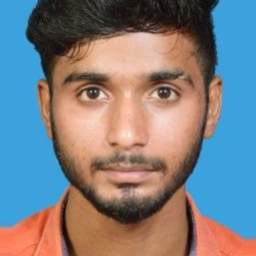

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import os

mp_face = mp.solutions.face_mesh

def align_face_from_path(img_path, save_path="aligned_face.png", output_size=256, padding=40):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("Cannot read image: " + img_path)
    h, w = img.shape[:2]

    with mp_face.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True) as face:
        result = face.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if not result.multi_face_landmarks:
            print("No face detected in", img_path)
            return None

        lm = result.multi_face_landmarks[0].landmark

        left_eye_ids = [33, 133]
        right_eye_ids = [362, 263]

        left_eye = np.mean([(lm[i].x * w, lm[i].y * h) for i in left_eye_ids], axis=0)
        right_eye = np.mean([(lm[i].x * w, lm[i].y * h) for i in right_eye_ids], axis=0)

        dx = right_eye[0] - left_eye[0]
        dy = right_eye[1] - left_eye[1]
        angle = np.degrees(np.arctan2(dy, dx))

        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        rotated = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

        lm_points = np.array([[p.x * w, p.y * h] for p in lm])
        ones = np.ones((lm_points.shape[0], 1))
        lm_homo = np.hstack([lm_points, ones])
        rotated_lm = lm_homo.dot(M.T)

        x_min, y_min = rotated_lm.min(axis=0).astype(int)
        x_max, y_max = rotated_lm.max(axis=0).astype(int)

        x_min = max(x_min - padding, 0)
        y_min = max(y_min - padding, 0)
        x_max = min(x_max + padding, rotated.shape[1])
        y_max = min(y_max + padding, rotated.shape[0])

        crop = rotated[y_min:y_max, x_min:x_max]
        ch, cw = crop.shape[:2]
        if ch == 0 or cw == 0:
            print("Invalid crop region.")
            return None

        diff = abs(ch - cw)
        if ch > cw:
            pad_left = diff // 2
            pad_right = diff - pad_left
            crop = cv2.copyMakeBorder(crop, 0, 0, pad_left, pad_right, cv2.BORDER_REPLICATE)
        elif cw > ch:
            pad_top = diff // 2
            pad_bottom = diff - pad_top
            crop = cv2.copyMakeBorder(crop, pad_top, pad_bottom, 0, 0, cv2.BORDER_REPLICATE)

        aligned = cv2.resize(crop, (output_size, output_size))
        cv2.imwrite(save_path, aligned)
        return save_path

out = align_face_from_path(fn, save_path="/content/aligned_face.png")
if out:
    print("Saved aligned face to:", out)
    from IPython.display import Image, display
    display(Image(out))


In [ ]:
files.download("/content/aligned_face.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>